# Titanic 생존 예측 - Kaggle 예제

이 노트북은 Kaggle의 가장 유명한 입문용 대회인 Titanic 생존 예측 문제를 다룹니다.

**목표**: 승객의 정보를 바탕으로 타이타닉호 침몰 사고에서 생존 여부를 예측하는 이진 분류 문제

## 1. 라이브러리 임포트 및 설정

In [1]:
# 데이터 처리 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝 라이브러리
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 경고 메시지 제거
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac의 경우)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시드 설정
np.random.seed(42)

## 2. 데이터 로드 및 기본 정보 확인

실제 Kaggle 데이터를 사용하기 위해서는 Kaggle에서 데이터를 다운로드해야 합니다.
여기서는 Seaborn에 내장된 Titanic 데이터셋을 사용하겠습니다.

In [2]:
# Titanic 데이터셋 로드 (seaborn 내장 데이터)
df = sns.load_dataset('titanic')

print("데이터셋 크기:", df.shape)
print("\n첫 5행:")
df.head()

데이터셋 크기: (891, 15)

첫 5행:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# 데이터 기본 정보
print("데이터 정보:")
df.info()

print("\n기술 통계:")
df.describe()

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

기술 통계:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# 결측값 확인
print("결측값 현황:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# 결측값 비율
print("\n결측값 비율:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0])

결측값 현황:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

결측값 비율:
age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


## 3. 탐색적 데이터 분석 (EDA)

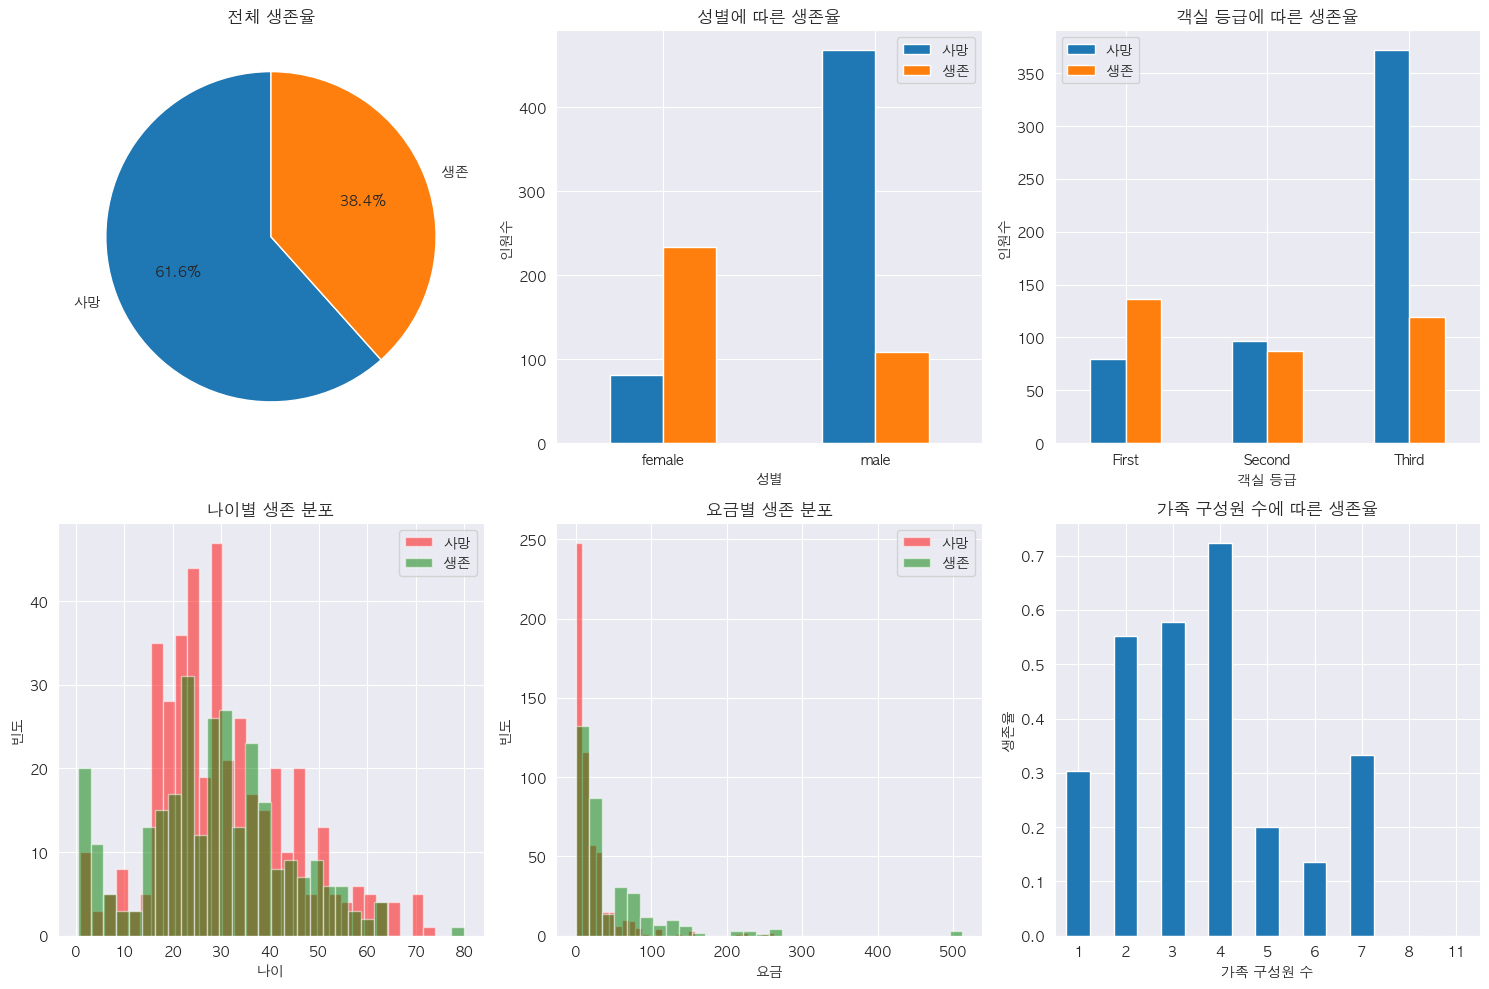

In [5]:
# 생존율 확인
plt.figure(figsize=(15, 10))

# 전체 생존율
plt.subplot(2, 3, 1)
survival_counts = df['survived'].value_counts()
plt.pie(survival_counts.values, labels=['사망', '생존'], autopct='%1.1f%%', startangle=90)
plt.title('전체 생존율')

# 성별에 따른 생존율
plt.subplot(2, 3, 2)
sex_survival = pd.crosstab(df['sex'], df['survived'])
sex_survival.plot(kind='bar', ax=plt.gca())
plt.title('성별에 따른 생존율')
plt.xlabel('성별')
plt.ylabel('인원수')
plt.legend(['사망', '생존'])
plt.xticks(rotation=0)

# 객실 등급에 따른 생존율
plt.subplot(2, 3, 3)
class_survival = pd.crosstab(df['class'], df['survived'])
class_survival.plot(kind='bar', ax=plt.gca())
plt.title('객실 등급에 따른 생존율')
plt.xlabel('객실 등급')
plt.ylabel('인원수')
plt.legend(['사망', '생존'])
plt.xticks(rotation=0)

# 나이 분포
plt.subplot(2, 3, 4)
plt.hist(df[df['survived']==0]['age'].dropna(), bins=30, alpha=0.5, label='사망', color='red')
plt.hist(df[df['survived']==1]['age'].dropna(), bins=30, alpha=0.5, label='생존', color='green')
plt.xlabel('나이')
plt.ylabel('빈도')
plt.title('나이별 생존 분포')
plt.legend()

# 요금 분포
plt.subplot(2, 3, 5)
plt.hist(df[df['survived']==0]['fare'].dropna(), bins=30, alpha=0.5, label='사망', color='red')
plt.hist(df[df['survived']==1]['fare'].dropna(), bins=30, alpha=0.5, label='생존', color='green')
plt.xlabel('요금')
plt.ylabel('빈도')
plt.title('요금별 생존 분포')
plt.legend()

# 가족 구성원 수에 따른 생존율
plt.subplot(2, 3, 6)
df['family_size'] = df['sibsp'] + df['parch'] + 1
family_survival = df.groupby('family_size')['survived'].mean()
family_survival.plot(kind='bar', ax=plt.gca())
plt.title('가족 구성원 수에 따른 생존율')
plt.xlabel('가족 구성원 수')
plt.ylabel('생존율')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

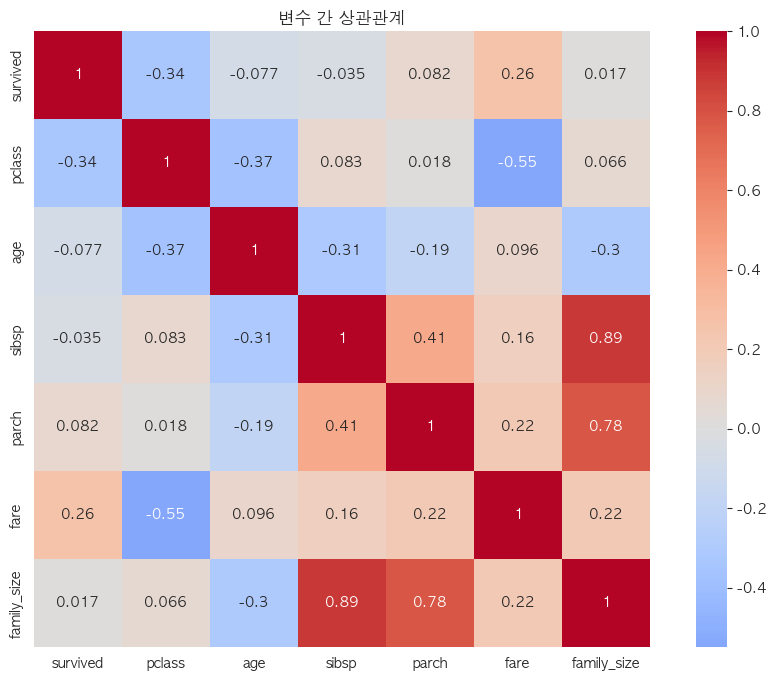

In [6]:
# 상관관계 히트맵
plt.figure(figsize=(12, 8))

# 수치형 변수들만 선택
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('변수 간 상관관계')
plt.show()

## 4. 데이터 전처리

In [7]:
# 데이터 복사본 생성
data = df.copy()

# 1. 결측값 처리
print("=== 결측값 처리 ===")

# 나이: 중앙값으로 대체
age_median = data['age'].median()
data['age'].fillna(age_median, inplace=True)
print(f"나이 결측값을 중앙값({age_median})으로 대체")

# 승선항구: 최빈값으로 대체
embark_mode = data['embark_town'].mode()[0]
data['embark_town'].fillna(embark_mode, inplace=True)
print(f"승선항구 결측값을 최빈값({embark_mode})으로 대체")

# deck은 결측값이 너무 많으므로 제거
data.drop('deck', axis=1, inplace=True)
print("deck 컬럼 제거 (결측값 과다)")

print(f"\n처리 후 결측값: {data.isnull().sum().sum()}개")

=== 결측값 처리 ===
나이 결측값을 중앙값(28.0)으로 대체
승선항구 결측값을 최빈값(Southampton)으로 대체
deck 컬럼 제거 (결측값 과다)

처리 후 결측값: 2개


In [8]:
# 2. 특성 공학 (Feature Engineering)
print("=== 특성 공학 ===")

# 가족 크기
data['family_size'] = data['sibsp'] + data['parch'] + 1
print("가족 크기 특성 생성")

# 혼자 여행 여부
data['is_alone'] = (data['family_size'] == 1).astype(int)
print("혼자 여행 여부 특성 생성")

# 나이 그룹
data['age_group'] = pd.cut(data['age'], bins=[0, 18, 35, 60, 100], 
                          labels=['Child', 'Young Adult', 'Adult', 'Senior'])
print("나이 그룹 특성 생성")

# 요금 그룹
data['fare_group'] = pd.qcut(data['fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
print("요금 그룹 특성 생성")

print(f"\n현재 컬럼 수: {len(data.columns)}개")

=== 특성 공학 ===
가족 크기 특성 생성
혼자 여행 여부 특성 생성
나이 그룹 특성 생성
요금 그룹 특성 생성

현재 컬럼 수: 18개


In [9]:
# 3. 범주형 변수 인코딩
print("=== 범주형 변수 인코딩 ===")

# 레이블 인코딩이 필요한 컬럼들
categorical_columns = ['sex', 'embark_town', 'class', 'who', 'adult_male', 'alone', 'age_group', 'fare_group']

label_encoders = {}
for column in categorical_columns:
    if column in data.columns:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column].astype(str))
        label_encoders[column] = le
        print(f"{column} 레이블 인코딩 완료")

print("\n인코딩 완료")

=== 범주형 변수 인코딩 ===
sex 레이블 인코딩 완료
embark_town 레이블 인코딩 완료
class 레이블 인코딩 완료
who 레이블 인코딩 완료
adult_male 레이블 인코딩 완료
alone 레이블 인코딩 완료
age_group 레이블 인코딩 완료
fare_group 레이블 인코딩 완료

인코딩 완료


In [13]:
# 4. 특성과 타겟 분리
# 불필요한 컬럼 제거
columns_to_drop = ['alive']  # 'survived'와 중복되는 정보
if 'alive' in data.columns:
    data.drop(columns_to_drop, axis=1, inplace=True)

# 특성과 타겟 분리
X = data.drop('survived', axis=1)
y = data['survived']

print(f"특성 개수: {X.shape[1]}개")
print(f"데이터 개수: {X.shape[0]}개")
print(f"\n사용할 특성들: {list(X.columns)}")

특성 개수: 16개
데이터 개수: 891개

사용할 특성들: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone', 'family_size', 'is_alone', 'age_group', 'fare_group']


In [14]:
X = pd.get_dummies(X, drop_first=True)
print(f"인코딩 후 특성 개수: {X.shape[1]}")
print(f"특성 타입:\n{X.dtypes}")

인코딩 후 특성 개수: 17
특성 타입:
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
class            int64
who              int64
adult_male       int64
embark_town      int64
alone            int64
family_size      int64
is_alone         int64
age_group        int64
fare_group       int64
embarked_Q        bool
embarked_S        bool
dtype: object


In [15]:
# 5. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"훈련 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")
print(f"\n훈련 데이터 생존율: {y_train.mean():.3f}")
print(f"테스트 데이터 생존율: {y_test.mean():.3f}")

훈련 데이터: (712, 17)
테스트 데이터: (179, 17)

훈련 데이터 생존율: 0.383
테스트 데이터 생존율: 0.385


In [16]:
# 6. 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("데이터 스케일링 완료")
print(f"스케일링 전 나이 평균: {X_train['age'].mean():.2f}")
print(f"스케일링 후 나이 평균: {X_train_scaled[:, X_train.columns.get_loc('age')].mean():.2f}")

데이터 스케일링 완료
스케일링 전 나이 평균: 29.46
스케일링 후 나이 평균: 0.00


## 5. 모델 학습 및 평가

In [17]:
# 여러 모델 정의
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True)
}

# 모델별 성능 저장
model_scores = {}
trained_models = {}

print("=== 모델 학습 및 교차 검증 ===")

for name, model in models.items():
    # 교차 검증
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # 모델 학습
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_pred = model.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, y_pred)
    
    # 결과 저장
    model_scores[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_accuracy
    }
    trained_models[name] = model
    
    print(f"{name}:")
    print(f"  교차 검증 평균: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  테스트 정확도: {test_accuracy:.4f}")
    print()

=== 모델 학습 및 교차 검증 ===
Logistic Regression:
  교차 검증 평균: 0.8133 (+/- 0.0487)
  테스트 정확도: 0.8324

Random Forest:
  교차 검증 평균: 0.7993 (+/- 0.0922)
  테스트 정확도: 0.8156

SVM:
  교차 검증 평균: 0.8189 (+/- 0.0263)
  테스트 정확도: 0.8268



In [18]:
# 최고 성능 모델 찾기
best_model_name = max(model_scores.keys(), key=lambda x: model_scores[x]['test_accuracy'])
best_model = trained_models[best_model_name]

print(f"최고 성능 모델: {best_model_name}")
print(f"테스트 정확도: {model_scores[best_model_name]['test_accuracy']:.4f}")

# 최고 모델로 예측
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, 'predict_proba') else None

최고 성능 모델: Logistic Regression
테스트 정확도: 0.8324


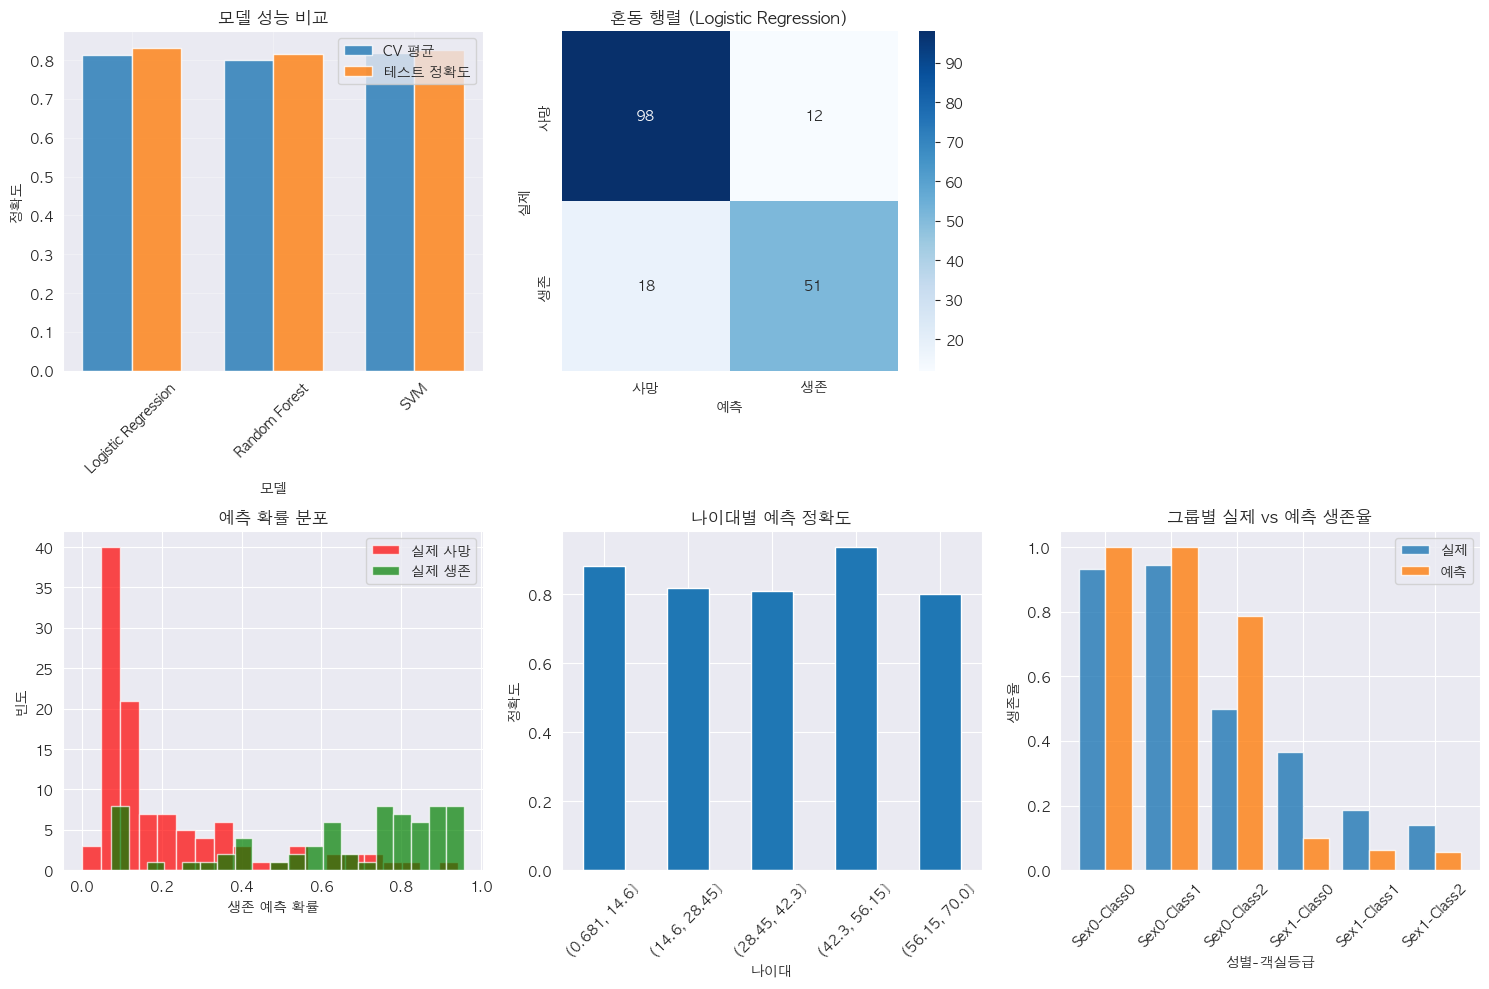

In [19]:
# 모델 성능 시각화
plt.figure(figsize=(15, 10))

# 모델 성능 비교
plt.subplot(2, 3, 1)
model_names = list(model_scores.keys())
test_accuracies = [model_scores[name]['test_accuracy'] for name in model_names]
cv_means = [model_scores[name]['cv_mean'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, cv_means, width, label='CV 평균', alpha=0.8)
plt.bar(x + width/2, test_accuracies, width, label='테스트 정확도', alpha=0.8)
plt.xlabel('모델')
plt.ylabel('정확도')
plt.title('모델 성능 비교')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 혼동 행렬
plt.subplot(2, 3, 2)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['사망', '생존'], yticklabels=['사망', '생존'])
plt.title(f'혼동 행렬 ({best_model_name})')
plt.ylabel('실제')
plt.xlabel('예측')

# 특성 중요도 (Random Forest인 경우)
if best_model_name == 'Random Forest':
    plt.subplot(2, 3, 3)
    feature_importance = best_model.feature_importances_
    feature_names = X.columns
    
    # 중요도 순으로 정렬
    indices = np.argsort(feature_importance)[::-1]
    
    plt.bar(range(len(feature_importance)), feature_importance[indices])
    plt.xticks(range(len(feature_importance)), [feature_names[i] for i in indices], rotation=45)
    plt.title('특성 중요도')
    plt.ylabel('중요도')

# 예측 확률 분포
if y_prob_best is not None:
    plt.subplot(2, 3, 4)
    plt.hist(y_prob_best[y_test == 0], bins=20, alpha=0.7, label='실제 사망', color='red')
    plt.hist(y_prob_best[y_test == 1], bins=20, alpha=0.7, label='실제 생존', color='green')
    plt.xlabel('생존 예측 확률')
    plt.ylabel('빈도')
    plt.title('예측 확률 분포')
    plt.legend()

# 나이별 생존 예측
plt.subplot(2, 3, 5)
age_survival_pred = pd.DataFrame({
    'age': X_test['age'],
    'actual': y_test,
    'predicted': y_pred_best
})

age_groups = pd.cut(age_survival_pred['age'], bins=5)
age_accuracy = age_survival_pred.groupby(age_groups).apply(
    lambda x: (x['actual'] == x['predicted']).mean()
)

age_accuracy.plot(kind='bar', ax=plt.gca())
plt.title('나이대별 예측 정확도')
plt.xlabel('나이대')
plt.ylabel('정확도')
plt.xticks(rotation=45)

# 성별-객실등급별 생존율 vs 예측
plt.subplot(2, 3, 6)
comparison_df = pd.DataFrame({
    'sex': X_test['sex'],
    'class': X_test['class'],
    'actual': y_test,
    'predicted': y_pred_best
})

actual_by_group = comparison_df.groupby(['sex', 'class'])['actual'].mean()
pred_by_group = comparison_df.groupby(['sex', 'class'])['predicted'].mean()

x_pos = np.arange(len(actual_by_group))
plt.bar(x_pos - 0.2, actual_by_group.values, 0.4, label='실제', alpha=0.8)
plt.bar(x_pos + 0.2, pred_by_group.values, 0.4, label='예측', alpha=0.8)
plt.xlabel('성별-객실등급')
plt.ylabel('생존율')
plt.title('그룹별 실제 vs 예측 생존율')
plt.xticks(x_pos, [f'Sex{s}-Class{c}' for s, c in actual_by_group.index], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# 상세한 분류 보고서
print("=== 상세한 분류 보고서 ===")
print(classification_report(y_test, y_pred_best, target_names=['사망', '생존']))

# 예측 오류 분석
print("\n=== 예측 오류 분석 ===")
errors = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_best,
    'age': X_test['age'],
    'sex': X_test['sex'],
    'class': X_test['class'],
    'fare': X_test['fare']
})

# 잘못 예측된 케이스들
wrong_predictions = errors[errors['actual'] != errors['predicted']]
print(f"총 예측 오류: {len(wrong_predictions)}개 ({len(wrong_predictions)/len(y_test)*100:.1f}%)")

# 오류 타입별 분석
false_positives = wrong_predictions[wrong_predictions['predicted'] == 1]  # 생존 예측했지만 실제 사망
false_negatives = wrong_predictions[wrong_predictions['predicted'] == 0]  # 사망 예측했지만 실제 생존

print(f"False Positives (생존 예측 → 실제 사망): {len(false_positives)}개")
print(f"False Negatives (사망 예측 → 실제 생존): {len(false_negatives)}개")

=== 상세한 분류 보고서 ===
              precision    recall  f1-score   support

          사망       0.84      0.89      0.87       110
          생존       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


=== 예측 오류 분석 ===
총 예측 오류: 30개 (16.8%)
False Positives (생존 예측 → 실제 사망): 12개
False Negatives (사망 예측 → 실제 생존): 18개


## 6. 하이퍼파라미터 튜닝

In [21]:
# Random Forest 하이퍼파라미터 튜닝
print("=== Random Forest 하이퍼파라미터 튜닝 ===")

# 그리드 서치를 위한 파라미터 정의
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 그리드 서치 실행
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최적 교차 검증 점수: {grid_search.best_score_:.4f}")

# 최적화된 모델로 예측
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"튜닝 후 테스트 정확도: {tuned_accuracy:.4f}")
print(f"튜닝 전 테스트 정확도: {model_scores['Random Forest']['test_accuracy']:.4f}")
print(f"개선도: {tuned_accuracy - model_scores['Random Forest']['test_accuracy']:.4f}")

=== Random Forest 하이퍼파라미터 튜닝 ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
최적 교차 검증 점수: 0.8287
튜닝 후 테스트 정확도: 0.8156
튜닝 전 테스트 정확도: 0.8156
개선도: 0.0000


## 7. 결과 해석 및 인사이트

In [22]:
# 최종 결과 요약
print("=== 타이타닉 생존 예측 분석 결과 ===")
print()

print("1. 데이터셋 정보:")
print(f"   - 총 승객 수: {len(df)}명")
print(f"   - 전체 생존율: {df['survived'].mean():.1%}")
print(f"   - 사용된 특성 수: {X.shape[1]}개")
print()

print("2. 주요 발견사항:")
print(f"   - 여성 생존율: {df[df['sex']=='female']['survived'].mean():.1%}")
print(f"   - 남성 생존율: {df[df['sex']=='male']['survived'].mean():.1%}")
print(f"   - 1등급 객실 생존율: {df[df['class']=='First']['survived'].mean():.1%}")
print(f"   - 3등급 객실 생존율: {df[df['class']=='Third']['survived'].mean():.1%}")
print()

print("3. 모델 성능:")
for name, scores in model_scores.items():
    print(f"   - {name}: {scores['test_accuracy']:.1%}")
print(f"   - 튜닝 후 Random Forest: {tuned_accuracy:.1%}")
print()

print("4. 핵심 인사이트:")
print("   - 성별이 생존에 가장 큰 영향을 미침 (여성 우선 구조)")
print("   - 객실 등급이 높을수록 생존율이 높음 (사회경제적 지위)")
print("   - 나이가 어릴수록 생존율이 높음 (어린이 우선 구조)")
print("   - 가족과 함께 탑승한 경우 생존율에 복합적 영향")
print()

print("5. 모델 활용 방안:")
print("   - 비상 상황에서의 대피 계획 수립")
print("   - 안전 규정 및 절차 개선")
print("   - 위험 요소 사전 식별 및 관리")

=== 타이타닉 생존 예측 분석 결과 ===

1. 데이터셋 정보:
   - 총 승객 수: 891명
   - 전체 생존율: 38.4%
   - 사용된 특성 수: 17개

2. 주요 발견사항:
   - 여성 생존율: 74.2%
   - 남성 생존율: 18.9%
   - 1등급 객실 생존율: 63.0%
   - 3등급 객실 생존율: 24.2%

3. 모델 성능:
   - Logistic Regression: 83.2%
   - Random Forest: 81.6%
   - SVM: 82.7%
   - 튜닝 후 Random Forest: 81.6%

4. 핵심 인사이트:
   - 성별이 생존에 가장 큰 영향을 미침 (여성 우선 구조)
   - 객실 등급이 높을수록 생존율이 높음 (사회경제적 지위)
   - 나이가 어릴수록 생존율이 높음 (어린이 우선 구조)
   - 가족과 함께 탑승한 경우 생존율에 복합적 영향

5. 모델 활용 방안:
   - 비상 상황에서의 대피 계획 수립
   - 안전 규정 및 절차 개선
   - 위험 요소 사전 식별 및 관리
